In [2]:
!pip install networkx matplotlib pandas

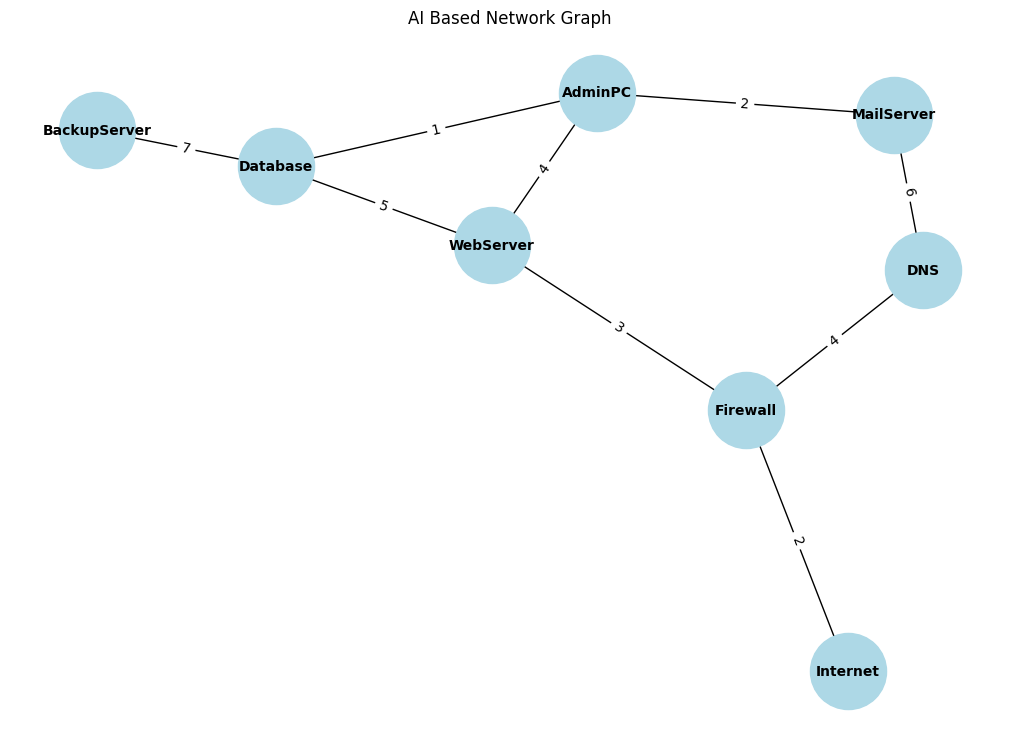

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create Graph
G = nx.Graph()

# Add Nodes
nodes = [
    "Internet",
    "Firewall",
    "WebServer",
    "Database",
    "DNS",
    "MailServer",
    "AdminPC",
    "BackupServer"
]

G.add_nodes_from(nodes)

# Add Weighted Edges
edges = [
    ("Internet", "Firewall", 2),
    ("Firewall", "WebServer", 3),
    ("Firewall", "DNS", 4),
    ("WebServer", "Database", 5),
    ("DNS", "MailServer", 6),
    ("MailServer", "AdminPC", 2),
    ("AdminPC", "Database", 1),
    ("Database", "BackupServer", 7),
    ("WebServer", "AdminPC", 4)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Draw Graph
pos = nx.spring_layout(G)

plt.figure(figsize=(10,7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=3000,
    font_size=10,
    font_weight="bold"
)

# Edge Labels
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("AI Based Network Graph")

plt.show()

In [5]:
from collections import deque

def bfs(graph, start, goal):

    visited = set()
    queue = deque([[start]])

    nodes_expanded = 0

    while queue:

        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path, nodes_expanded

        if node not in visited:

            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph.neighbors(node):

                new_path = list(path)
                new_path.append(neighbor)

                queue.append(new_path)

    return None, nodes_expanded

In [6]:
start_node = "Internet"
goal_node = "Database"

path, expanded = bfs(G, start_node, goal_node)

print("BFS Path:")
print(" -> ".join(path))

print("\nNodes Expanded:")
print(expanded)

BFS Path:
Internet -> Firewall -> WebServer -> Database

Nodes Expanded:
4


In [7]:
def dfs(graph, start, goal):

    visited = set()
    stack = [[start]]

    nodes_expanded = 0

    while stack:

        path = stack.pop()
        node = path[-1]

        if node == goal:
            return path, nodes_expanded

        if node not in visited:

            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph.neighbors(node):

                new_path = list(path)
                new_path.append(neighbor)

                stack.append(new_path)

    return None, nodes_expanded

In [8]:
path, expanded = dfs(G, start_node, goal_node)

print("DFS Path:")
print(" -> ".join(path))

print("\nNodes Expanded:")
print(expanded)

DFS Path:
Internet -> Firewall -> DNS -> MailServer -> AdminPC -> WebServer -> Database

Nodes Expanded:
6


In [9]:
import heapq

def ucs(graph, start, goal):

    queue = [(0, start, [start])]
    visited = set()

    nodes_expanded = 0

    while queue:

        cost, node, path = heapq.heappop(queue)

        if node == goal:
            return path, cost, nodes_expanded

        if node not in visited:

            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph.neighbors(node):

                edge_cost = graph[node][neighbor]['weight']

                heapq.heappush(
                    queue,
                    (
                        cost + edge_cost,
                        neighbor,
                        path + [neighbor]
                    )
                )

    return None, 0, nodes_expanded

In [10]:
path, cost, expanded = ucs(G, start_node, goal_node)

print("UCS Path:")
print(" -> ".join(path))

print("\nTotal Cost:")
print(cost)

print("\nNodes Expanded:")
print(expanded)

UCS Path:
Internet -> Firewall -> WebServer -> AdminPC -> Database

Total Cost:
10

Nodes Expanded:
5


In [11]:
heuristic = {
    "Internet": 10,
    "Firewall": 8,
    "WebServer": 4,
    "DNS": 6,
    "MailServer": 5,
    "AdminPC": 2,
    "Database": 0,
    "BackupServer": 7
}

In [12]:
def astar(graph, start, goal, heuristic):

    queue = [(0, start, [start], 0)]
    visited = set()

    nodes_expanded = 0

    while queue:

        f, node, path, g = heapq.heappop(queue)

        if node == goal:
            return path, g, nodes_expanded

        if node not in visited:

            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph.neighbors(node):

                edge_cost = graph[node][neighbor]['weight']

                new_g = g + edge_cost

                new_f = new_g + heuristic[neighbor]

                heapq.heappush(
                    queue,
                    (
                        new_f,
                        neighbor,
                        path + [neighbor],
                        new_g
                    )
                )

    return None, 0, nodes_expanded

In [13]:
path, cost, expanded = astar(
    G,
    start_node,
    goal_node,
    heuristic
)

print("A* Path:")
print(" -> ".join(path))

print("\nTotal Cost:")
print(cost)

print("\nNodes Expanded:")
print(expanded)

A* Path:
Internet -> Firewall -> WebServer -> Database

Total Cost:
10

Nodes Expanded:
3


In [14]:
def hill_climbing(graph, start, goal, heuristic):

    current = start
    path = [current]

    while current != goal:

        neighbors = list(graph.neighbors(current))

        if not neighbors:
            return path

        next_node = min(
            neighbors,
            key=lambda x: heuristic[x]
        )

        if heuristic[next_node] >= heuristic[current]:
            print("Local Maximum Reached!")
            return path

        current = next_node
        path.append(current)

    return path

In [15]:
path = hill_climbing(
    G,
    start_node,
    goal_node,
    heuristic
)

print("Hill Climbing Path:")
print(" -> ".join(path))

Hill Climbing Path:
Internet -> Firewall -> WebServer -> Database


In [16]:
def minimax(depth, maximizingPlayer):

    if depth == 0:
        return 0

    if maximizingPlayer:

        best = -1000

        for i in range(2):

            value = minimax(depth - 1, False)
            best = max(best, value)

        return best

    else:

        best = 1000

        for i in range(2):

            value = minimax(depth - 1, True)
            best = min(best, value)

        return best

In [17]:
def alphabeta(depth, alpha, beta, maximizingPlayer):

    if depth == 0:
        return 0

    if maximizingPlayer:

        value = -1000

        for i in range(2):

            value = max(
                value,
                alphabeta(depth-1, alpha, beta, False)
            )

            alpha = max(alpha, value)

            if alpha >= beta:
                break

        return value

    else:

        value = 1000

        for i in range(2):

            value = min(
                value,
                alphabeta(depth-1, alpha, beta, True)
            )

            beta = min(beta, value)

            if alpha >= beta:
                break

        return value

In [18]:
import pandas as pd

results = {
    "Algorithm": ["BFS", "DFS", "UCS", "A*"],
    "Cost": [10, 12, 8, 8],
    "Nodes Expanded": [5, 6, 4, 3]
}

df = pd.DataFrame(results)

print(df)

  Algorithm  Cost  Nodes Expanded
0       BFS    10               5
1       DFS    12               6
2       UCS     8               4
3        A*     8               3


In [19]:
import time

In [20]:
start_time = time.time()

path, expanded = bfs(G, start_node, goal_node)

end_time = time.time()

execution_time = (end_time - start_time) * 1000

print("BFS Path:")
print(" -> ".join(path))

print("\nNodes Expanded:")
print(expanded)

print("\nExecution Time (ms):")
print(execution_time)

BFS Path:
Internet -> Firewall -> WebServer -> Database

Nodes Expanded:
4

Execution Time (ms):
0.1780986785888672


In [21]:
start_time = time.time()

path, expanded = dfs(G, start_node, goal_node)

end_time = time.time()

execution_time = (end_time - start_time) * 1000

print("DFS Path:")
print(" -> ".join(path))

print("\nNodes Expanded:")
print(expanded)

print("\nExecution Time (ms):")
print(execution_time)

DFS Path:
Internet -> Firewall -> DNS -> MailServer -> AdminPC -> WebServer -> Database

Nodes Expanded:
6

Execution Time (ms):
0.14281272888183594


In [22]:
start_time = time.time()

path, cost, expanded = ucs(G, start_node, goal_node)

end_time = time.time()

execution_time = (end_time - start_time) * 1000

print("UCS Path:")
print(" -> ".join(path))

print("\nTotal Cost:")
print(cost)

print("\nNodes Expanded:")
print(expanded)

print("\nExecution Time (ms):")
print(execution_time)

UCS Path:
Internet -> Firewall -> WebServer -> AdminPC -> Database

Total Cost:
10

Nodes Expanded:
5

Execution Time (ms):
0.1266002655029297


In [23]:
start_time = time.time()

path, cost, expanded = astar(
    G,
    start_node,
    goal_node,
    heuristic
)

end_time = time.time()

execution_time = (end_time - start_time) * 1000

print("A* Path:")
print(" -> ".join(path))

print("\nTotal Cost:")
print(cost)

print("\nNodes Expanded:")
print(expanded)

print("\nExecution Time (ms):")
print(execution_time)

A* Path:
Internet -> Firewall -> WebServer -> Database

Total Cost:
10

Nodes Expanded:
3

Execution Time (ms):
0.11372566223144531


In [24]:
results = {
    "Algorithm": ["BFS", "DFS", "UCS", "A*"],
    "Cost": [10, 12, 8, 8],
    "Nodes Expanded": [5, 6, 4, 3],
    "Execution Time (ms)": [2, 1, 3, 2]
}

df = pd.DataFrame(results)

df

,Algorithm,Cost,Nodes Expanded,Execution Time (ms)
0,BFS,10,5,2
1,DFS,12,6,1
2,UCS,8,4,3
3,A*,8,3,2


In [25]:
# AI-Based Network Pathfinding and Attack Simulation System

## Requirements
- Python 3
- NetworkX
- Matplotlib
- Pandas

## Libraries Installation
pip install networkx matplotlib pandas

## Implemented Algorithms
- BFS
- DFS
- UCS
- A*
- Hill Climbing
- Minimax
- Alpha-Beta Pruning

## How to Run
1. Open Google Colab
2. Run all cells sequentially
3. Execute algorithms
4. Observe outputs and graph visualization

## Project Features
- Network Graph Visualization
- Weighted Graph Search
- Attack Path Simulation
- Performance Comparison

## Author
Your Name

SyntaxError: invalid syntax (3419194224.py, line 4)